# emp_model_v5

**Changes vs v4.1:**
1. **Reuses v4.1 full-image features** — loads `cradio_v41_embeddings.pt` (3840-d, 8 views + patch tokens, fine-tuned backbone) directly; no re-extraction
2. **Dual-crop feature streams** — portrait (center 65%) + legend ring (outer 35%) extracted with the same fine-tuned C-RADIO → two 2560-d vectors per image
3. **DINOv2-ViT-G/14** second backbone — 1536-d CLS token, complementary error geometry
4. **Combined 10496-d features** — `[cradio_v41_full(3840) | cradio_portrait(2560) | cradio_legend(2560) | dino_full(1536)]`
5. **Cosine classifier** — same as v3-TTA (ArcFace underperformed in v4)
6. **CE + Mixup + SupCon** — supervised contrastive loss with 3× upweighting on hard-confusion cluster pairs

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re, math, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from datetime import datetime
from pathlib import Path
from PIL import Image


In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False
    print('Not running on Colab — skipping drive.mount.')


Not running on Colab — skipping drive.mount.


In [3]:
if ON_COLAB:
    DATA_DIR = r'/content/drive/MyDrive/coin_dataset'
else:
    DATA_DIR = r'/home/david/coin/FOR_TRAINNING'


In [4]:
def folder_label(name):
    return re.sub(r'^\d+_', '', name)

unique_labels = sorted({folder_label(p.name) for p in Path(DATA_DIR).iterdir()
                        if p.is_dir() and (p / 'side_a').exists()})
label_encoder = {name: i for i, name in enumerate(unique_labels)}
num_classes   = len(label_encoder)
print(f'{num_classes} classes from folder structure.')


52 classes from folder structure.


In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda:0


## Feature Extraction — Load v4.1 Full-Image + Extract 2 New Crops + DINOv2-g

**Stream 1 — C-RADIO full image (3840-d, already computed):**
- Loaded from `cradio_v41_embeddings.pt` — fine-tuned backbone, 8 TTA views, summary (2560) + patch_mean (1280)

**Stream 2 — C-RADIO portrait crop (2560-d, 4 TTA views, new):**
- Center 65% square crop; directs the backbone entirely at facial/portrait features

**Stream 3 — C-RADIO legend crop (2560-d, 4 TTA views, new):**
- Outer annular ring (center 65% blacked out); forces the backbone to read inscription text only

**Stream 4 — DINOv2-ViT-G/14 full image (1536-d, 4 TTA views, new):**
- Patch-level self-distillation gives spatially richer embeddings; different error geometry reduces correlated mistakes

All new chunk files are saved individually so a crash/interrupt loses at most one chunk.

In [6]:
PORTRAIT_FRAC = 0.65   # inner circle fraction for portrait / legend boundary

image_dir  = Path(DATA_DIR)
filepaths  = sorted(image_dir.glob('*/side_a/*.jpg'))
raw_labels = [folder_label(p.parent.parent.name) for p in filepaths]
labels_int = [label_encoder[l] for l in raw_labels]
print(f'Total images: {len(filepaths)}')

VIEWS = [
    ('r256',      256, False),
    ('r256_flip', 256, True),
    ('r384',      384, False),
    ('r384_flip', 384, True),
]
NUM_CHUNKS    = 10
EXTRACT_BATCH = 8


def chunk_ranges(n_total, n_chunks):
    edges = np.linspace(0, n_total, n_chunks + 1, dtype=int)
    return [(i, int(edges[i]), int(edges[i + 1])) for i in range(n_chunks)]

ranges = chunk_ranges(len(filepaths), NUM_CHUNKS)


def portrait_crop(img: Image.Image) -> Image.Image:
    """Square center crop at PORTRAIT_FRAC of the shorter side."""
    w, h  = img.size
    side  = int(min(w, h) * PORTRAIT_FRAC)
    cx, cy = w // 2, h // 2
    l, t  = cx - side // 2, cy - side // 2
    return img.crop((l, t, l + side, t + side))


def legend_crop(img: Image.Image) -> Image.Image:
    """Black out the centre circle (portrait region), keeping only the legend ring."""
    arr  = np.array(img.convert('RGB'), dtype=np.uint8).copy()
    h, w = arr.shape[:2]
    cx, cy = w // 2, h // 2
    r    = int(min(w, h) * PORTRAIT_FRAC / 2)
    Y, X = np.ogrid[:h, :w]
    arr[(X - cx) ** 2 + (Y - cy) ** 2 <= r ** 2] = 0
    return Image.fromarray(arr)


CROP_FNS = {
    'full':     lambda img: img,
    'portrait': portrait_crop,
    'legend':   legend_crop,
}


Total images: 62134


In [7]:
# ── Fine-tuned C-RADIO crop extraction (portrait + legend only) ────────────────
# Full-image features already exist as cradio_v41_embeddings.pt (3840-d,
# 8 views + patch tokens, fine-tuned backbone) from v4.1 — loaded directly later.
# Only the two new crop streams need extracting here:
#   portrait × 4 views × 10 chunks = 40 chunk files
#   legend   × 4 views × 10 chunks = 40 chunk files  → 80 total

CROP_FNS_NEW = {
    'portrait': portrait_crop,
    'legend':   legend_crop,
}


class CoinCropDataset(Dataset):
    def __init__(self, fps, labs, crop_fn, resolution, flip):
        self.fps = fps; self.labs = labs
        self.crop_fn = crop_fn; self.resolution = resolution; self.flip = flip

    def __len__(self): return len(self.fps)

    def __getitem__(self, i):
        img = Image.open(self.fps[i]).convert('RGB')
        img = self.crop_fn(img)
        img = img.resize((self.resolution, self.resolution), Image.BILINEAR)
        if self.flip:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        arr = torch.from_numpy(np.array(img)).permute(2, 0, 1).float().div_(255.0)
        return arr, torch.tensor(self.labs[i], dtype=torch.long)


@torch.no_grad()
def run_cradio_chunk(model, sub_fp, sub_lb, crop_fn, resolution, flip):
    ds     = CoinCropDataset(sub_fp, sub_lb, crop_fn, resolution, flip)
    loader = DataLoader(ds, batch_size=EXTRACT_BATCH, shuffle=False,
                        num_workers=2, pin_memory=True)
    feats, labs = [], []
    for j, (imgs, l) in enumerate(loader):
        imgs = imgs.to(device)
        with torch.autocast('cuda', dtype=torch.bfloat16):
            summary, _ = model(imgs)
        feats.append(summary.float().cpu())
        labs.append(l)
        if (j + 1) % 100 == 0:
            print(f'      batch {j + 1}/{len(loader)}')
    return torch.cat(feats), torch.cat(labs)


cradio_root  = Path(DATA_DIR) / 'cradio_v5_chunks'
cradio_crops = Path(DATA_DIR) / 'cradio_v5_crops.pt'   # portrait + legend only
cradio_root.mkdir(parents=True, exist_ok=True)

if cradio_crops.exists():
    print('C-RADIO v5 crop embeddings already exist — skipping extraction.')
else:
    missing_cr = [
        (crop_name, view_name, res, flip, idx, start, end,
         cradio_root / f'{crop_name}_{view_name}_chunk_{idx:02d}.pt')
        for crop_name in CROP_FNS_NEW
        for view_name, res, flip in VIEWS
        for idx, start, end in ranges
        if not (cradio_root / f'{crop_name}_{view_name}_chunk_{idx:02d}.pt').exists()
    ]

    if not missing_cr:
        print('All C-RADIO v5 crop chunks on disk — skipping backbone load.')
    else:
        n_total_cr = len(CROP_FNS_NEW) * len(VIEWS) * NUM_CHUNKS
        print(f'{len(missing_cr)}/{n_total_cr} chunks missing. Loading fine-tuned C-RADIO...')
        import warnings
        radio_ft = torch.hub.load('NVlabs/RADIO', 'radio_model',
                                   version='c-radio_v4-h', progress=True)
        ft_ckpt  = torch.load('/home/david/coin/emp_model_v4_finetuned.pth', map_location='cpu')
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            radio_ft.load_state_dict(ft_ckpt['radio'], strict=False)
        radio_ft = radio_ft.to(device).eval()
        for p in radio_ft.parameters():
            p.requires_grad = False
        print('Fine-tuned C-RADIO v4-H loaded.')

        for crop_name, view_name, res, flip, idx, start, end, out_path in missing_cr:
            print(f'  crop={crop_name}  view={view_name}  chunk {idx + 1}/{NUM_CHUNKS}  rows {start}:{end}')
            t0     = datetime.now()
            sub_fp = [str(p) for p in filepaths[start:end]]
            sub_lb = labels_int[start:end]
            feats, labs = run_cradio_chunk(radio_ft, sub_fp, sub_lb,
                                           CROP_FNS_NEW[crop_name], res, flip)
            torch.save({'features': feats, 'labels': labs}, out_path)
            print(f'    saved {out_path.name}  in {datetime.now() - t0}')

        del radio_ft
        torch.cuda.empty_cache()

    # Average across 4 views per crop type
    print('Averaging C-RADIO crop features across views...')
    label_tensor_cr = None
    crop_avgs       = {}
    for crop_name in CROP_FNS_NEW:
        summed = None
        for view_name, _, _ in VIEWS:
            parts  = [torch.load(cradio_root / f'{crop_name}_{view_name}_chunk_{i:02d}.pt')
                      for i in range(NUM_CHUNKS)]
            v      = torch.cat([d['features'] for d in parts])
            summed = v if summed is None else summed + v
            if label_tensor_cr is None:
                label_tensor_cr = torch.cat([d['labels'] for d in parts])
        crop_avgs[crop_name] = summed / len(VIEWS)
        print(f'  {crop_name}: {crop_avgs[crop_name].shape}')

    torch.save({
        'features_portrait': crop_avgs['portrait'],
        'features_legend':   crop_avgs['legend'],
        'labels':            label_tensor_cr,
    }, cradio_crops)
    print(f'Saved C-RADIO v5 crop embeddings -> {cradio_crops}')

C-RADIO v5 crop embeddings already exist — skipping extraction.


In [8]:
# ── DINOv2-ViT-G/14 extraction ─────────────────────────────────────────────────
# Full image only, 1536-d CLS token.
# DINOv2 patch size = 14, so input dimensions must be multiples of 14.
# Use 252 (14×18) ≈ 256 and 378 (14×27) ≈ 384.
# ImageNet normalisation required (DINOv2 was not trained with C-RADIO's conditioner).

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

DINO_VIEWS = [
    ('r252',      252, False),
    ('r252_flip', 252, True),
    ('r378',      378, False),
    ('r378_flip', 378, True),
]


class DinoCoinDataset(Dataset):
    def __init__(self, fps, labs, resolution, flip):
        self.fps = fps; self.labs = labs
        self.resolution = resolution; self.flip = flip

    def __len__(self): return len(self.fps)

    def __getitem__(self, i):
        img = Image.open(self.fps[i]).convert('RGB')
        img = img.resize((self.resolution, self.resolution), Image.BILINEAR)
        if self.flip:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        arr = torch.from_numpy(np.array(img)).permute(2, 0, 1).float().div_(255.0)
        arr = (arr - IMAGENET_MEAN) / IMAGENET_STD
        return arr, torch.tensor(self.labs[i], dtype=torch.long)


@torch.no_grad()
def run_dino_chunk(model, sub_fp, sub_lb, resolution, flip):
    ds     = DinoCoinDataset(sub_fp, sub_lb, resolution, flip)
    loader = DataLoader(ds, batch_size=EXTRACT_BATCH, shuffle=False,
                        num_workers=2, pin_memory=True)
    feats, labs = [], []
    for j, (imgs, l) in enumerate(loader):
        imgs = imgs.to(device)
        with torch.autocast('cuda', dtype=torch.bfloat16):
            f = model(imgs)   # (B, 1536) CLS token
        feats.append(f.float().cpu())
        labs.append(l)
        if (j + 1) % 100 == 0:
            print(f'      batch {j + 1}/{len(loader)}')
    return torch.cat(feats), torch.cat(labs)


dino_root  = Path(DATA_DIR) / 'dino_v5_chunks'
dino_final = Path(DATA_DIR) / 'dino_v5_embeddings.pt'
dino_root.mkdir(parents=True, exist_ok=True)

if dino_final.exists():
    print(f'DINOv2 embeddings already exist — skipping extraction.')
else:
    missing_dino = [
        (view_name, res, flip, idx, start, end,
         dino_root / f'{view_name}_chunk_{idx:02d}.pt')
        for view_name, res, flip in DINO_VIEWS
        for idx, start, end in ranges
        if not (dino_root / f'{view_name}_chunk_{idx:02d}.pt').exists()
    ]

    if not missing_dino:
        print('All DINOv2 chunks on disk — skipping backbone load.')
    else:
        print(f'{len(missing_dino)}/{len(DINO_VIEWS) * NUM_CHUNKS} DINOv2 chunks missing. '
              f'Loading DINOv2-ViT-G/14...')
        dino_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitg14')
        dino_model = dino_model.to(device).eval()
        for p in dino_model.parameters():
            p.requires_grad = False
        print('DINOv2-ViT-G/14 loaded (1.1 B params, 1536-d CLS, patch=14).')

        for view_name, res, flip, idx, start, end, out_path in missing_dino:
            print(f'  view={view_name}  chunk {idx + 1}/{NUM_CHUNKS}  rows {start}:{end}')
            t0     = datetime.now()
            sub_fp = [str(p) for p in filepaths[start:end]]
            sub_lb = labels_int[start:end]
            feats, labs = run_dino_chunk(dino_model, sub_fp, sub_lb, res, flip)
            torch.save({'features': feats, 'labels': labs}, out_path)
            print(f'    saved {out_path.name}  in {datetime.now() - t0}')

        del dino_model
        torch.cuda.empty_cache()

    print('Averaging DINOv2 features across views...')
    dino_sum = None; label_tensor_d = None
    for view_name, _, _ in DINO_VIEWS:
        parts    = [torch.load(dino_root / f'{view_name}_chunk_{i:02d}.pt')
                    for i in range(NUM_CHUNKS)]
        v        = torch.cat([d['features'] for d in parts])
        dino_sum = v if dino_sum is None else dino_sum + v
        if label_tensor_d is None:
            label_tensor_d = torch.cat([d['labels'] for d in parts])
    dino_avg = dino_sum / len(DINO_VIEWS)
    torch.save({'features': dino_avg, 'labels': label_tensor_d}, dino_final)
    print(f'Saved DINOv2 v5 embeddings -> {dino_final}  shape={dino_avg.shape}')

DINOv2 embeddings already exist — skipping extraction.


In [9]:
# ── Combine all feature streams ────────────────────────────────────────────────
# Stream 1: cradio_v41_embeddings.pt  — 3840-d  (8 views + patch, fine-tuned, full image)
# Stream 2: cradio_v5_crops.pt        — 2560-d portrait  + 2560-d legend  (4 views each)
# Stream 3: dino_v5_embeddings.pt     — 1536-d  (4 views, full image)
# Total: 3840 + 2560 + 2560 + 1536 = 10496-d

v41_path = Path(DATA_DIR) / 'cradio_v41_embeddings.pt'
v41_data  = torch.load(v41_path)
print(f'Loaded v4.1 embeddings: {v41_data["features"].shape}  labels={v41_data["labels"].shape}')

crops_data = torch.load(cradio_crops)
dino_data  = torch.load(dino_final)

assert torch.equal(v41_data['labels'], crops_data['labels']), \
    'Label mismatch between cradio_v41 and cradio_v5_crops!'
assert torch.equal(v41_data['labels'], dino_data['labels']), \
    'Label mismatch between cradio_v41 and dino_v5!'

all_feats = torch.cat([
    v41_data['features'],                # 3840-d  fine-tuned C-RADIO, full image (8 views + patch)
    crops_data['features_portrait'],     # 2560-d  fine-tuned C-RADIO, portrait crop
    crops_data['features_legend'],       # 2560-d  fine-tuned C-RADIO, legend ring
    dino_data['features'],               # 1536-d  DINOv2-g, full image
], dim=-1)
all_labs = v41_data['labels']

print(f'Combined features: {all_feats.shape}')
print(f'  cradio_v41 (full, 8v+patch) : {v41_data["features"].shape[1]}-d')
print(f'  cradio_portrait (4v)        : {crops_data["features_portrait"].shape[1]}-d')
print(f'  cradio_legend   (4v)        : {crops_data["features_legend"].shape[1]}-d')
print(f'  dino_full       (4v)        : {dino_data["features"].shape[1]}-d')
print(f'  total                       : {all_feats.shape[1]}-d')

Loaded v4.1 embeddings: torch.Size([62134, 3840])  labels=torch.Size([62134])
Combined features: torch.Size([62134, 10496])
  cradio_v41 (full, 8v+patch) : 3840-d
  cradio_portrait (4v)        : 2560-d
  cradio_legend   (4v)        : 2560-d
  dino_full       (4v)        : 1536-d
  total                       : 10496-d


In [10]:
# ── Label merge + stratified split (same seeds as all previous versions) ───────
MERGES = {'GORDIAN II': 'GORDIAN I'}

remap  = {label_encoder[src]: label_encoder[tgt] for src, tgt in MERGES.items()}
mapped = all_labs.clone()
for src_idx, tgt_idx in remap.items():
    mapped[all_labs == src_idx] = tgt_idx

kept_names        = [n for n in unique_labels if n not in MERGES]
new_label_encoder = {name: i for i, name in enumerate(kept_names)}
old_to_new        = {label_encoder[name]: new_label_encoder[name] for name in kept_names}

all_labs      = torch.tensor([old_to_new[int(x)] for x in mapped], dtype=torch.long)
label_encoder = new_label_encoder
idx_to_label  = {v: k for k, v in label_encoder.items()}
num_classes   = len(label_encoder)
print(f'After merge: {num_classes} classes.')

train_feats, test_feats, train_labs, test_labs = train_test_split(
    all_feats, all_labs, test_size=0.2, shuffle=True, stratify=all_labs, random_state=42)
train_feats, val_feats, train_labs, val_labs = train_test_split(
    train_feats, train_labs, test_size=0.2, shuffle=True, stratify=train_labs, random_state=42)

feat_dim = train_feats.shape[1]
print(f'Train: {len(train_feats)}  Val: {len(val_feats)}  Test: {len(test_feats)}')
print(f'Feature dim: {feat_dim}')


After merge: 51 classes.
Train: 39765  Val: 9942  Test: 12427
Feature dim: 10496


In [11]:
name_to_prefix = {
    re.sub(r'^\d+_', '', p.name): int(re.match(r'^(\d+)_', p.name).group(1))
    for p in Path(DATA_DIR).iterdir()
    if p.is_dir() and (p / 'side_a').exists()
}

def counts(labs):
    return pd.Series(labs.numpy()).value_counts()

train_c, val_c, test_c = counts(train_labs), counts(val_labs), counts(test_labs)
rows = []
for cls_idx in sorted(set(train_c.index) | set(val_c.index) | set(test_c.index)):
    name = idx_to_label[int(cls_idx)]
    rows.append((name_to_prefix.get(name, 99), name,
                 int(train_c.get(cls_idx, 0)),
                 int(val_c.get(cls_idx, 0)),
                 int(test_c.get(cls_idx, 0))))
rows.sort()
df_counts = pd.DataFrame(rows, columns=['#', 'Emperor', 'Train', 'Val', 'Test'])
df_counts['Total'] = df_counts[['Train', 'Val', 'Test']].sum(axis=1)
print(df_counts.to_string(index=False))
print(f"\nTotals -> Train: {df_counts.Train.sum()}  Val: {df_counts.Val.sum()}  "
      f"Test: {df_counts.Test.sum()}  ({len(df_counts)} classes)")


 #           Emperor  Train  Val  Test  Total
 1          AUGUSTUS   1074  269   336   1679
 2          TIBERIUS    527  132   165    824
 3          CALIGULA    506  126   158    790
 4          CLAUDIUS    882  221   276   1379
 5              NERO    926  232   290   1448
 6             GALBA    991  248   310   1549
 7              OTHO    411  103   129    643
 8         VITELLIUS    568  142   178    888
 9         VESPASIAN   1361  340   425   2126
10             TITUS   1121  280   350   1751
11          DOMITIAN   1309  327   409   2045
12             NERVA   1105  276   345   1726
13            TRAJAN   1066  267   333   1666
14           HADRIAN   1201  301   375   1877
15    ANTONINUS PIUS    613  153   192    958
16   MARCUS AURELIUS   1141  285   356   1782
17      LUCIUS VERUS    786  196   245   1227
18          COMMODUS   1122  281   351   1754
19          PERTINAX    992  248   310   1550
20   DIDIUS JULIANUS    507  127   158    792
21  SEPTIMUS SEVERUS   1501  375  

In [12]:
batch_size   = 512

class_counts  = torch.bincount(train_labs, minlength=num_classes).float()
beta          = 0.9999
effective_num = 1.0 - torch.pow(beta, class_counts)
cb_weights    = (1.0 - beta) / effective_num
cb_weights    = cb_weights / cb_weights.sum() * num_classes
cb_weights    = cb_weights.to(device)

sample_weights = cb_weights.cpu()[train_labs]
train_sampler  = WeightedRandomSampler(sample_weights, num_samples=len(train_labs),
                                        replacement=True)
train_loader = DataLoader(TensorDataset(train_feats, train_labs),
                           batch_size=batch_size, sampler=train_sampler)
val_loader   = DataLoader(TensorDataset(val_feats,   val_labs),
                           batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(test_feats,  test_labs),
                           batch_size=batch_size, shuffle=False)
print('Loaders ready.')


Loaders ready.


## Model — CoinHeadV5 with Cosine Classifier

Reverts to v3's cosine classifier (ArcFace underperformed in v4).
Wider first layer to handle the 10496-d input: 10496 → 2048 → 1024 → cosine[51].

In [13]:
class CosineClassifier(nn.Module):
    def __init__(self, in_dim, n_cls, scale=20.0):
        super().__init__()
        self.weight    = nn.Parameter(torch.randn(n_cls, in_dim) * 0.01)
        self.log_scale = nn.Parameter(torch.tensor(float(np.log(scale))))

    def forward(self, x):
        x = F.normalize(x, dim=-1)
        w = F.normalize(self.weight, dim=-1)
        return torch.exp(self.log_scale) * (x @ w.T)


class CoinHeadV5(nn.Module):
    def __init__(self, in_dim, n_cls, hidden=2048, dropout=0.3):
        super().__init__()
        self.body = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.cls = CosineClassifier(hidden // 2, n_cls)

    def forward(self, x):
        return self.cls(self.body(x))


print(f'CoinHeadV5: {feat_dim} -> LayerNorm -> {2048} -> {1024} -> cosine[{num_classes}]')


CoinHeadV5: 10496 -> LayerNorm -> 2048 -> 1024 -> cosine[51]


## Training Utilities — CE + Mixup + SupCon with Hard-Cluster Upweighting

**Supervised Contrastive loss** (Khosla et al. 2020) applied to the 1024-d body embedding.
Within-cluster confusion pairs (QUINTILLUS–AURELIAN, VALERIAN–AEMILIAN, etc.) contribute
3× more to the negative term of the denominator, directly penalising the specific confusions
we observed in v3/v4 error analysis.

Training step per batch:
1. **Mixed features** → body → classifier → CE + label-smoothing loss
2. **Clean features** (no mixup) → body → SupCon loss
3. Combined: `loss = CE + SC_WEIGHT * SupCon`


In [16]:
HARD_CLUSTERS = [
    ['QUINTILLUS', 'AURELIAN', 'CLAUDIUS GOTHICUS'],
    ['VALERIAN', 'AEMILIAN', 'GALLIENUS'],
    ['SEPTIMUS SEVERUS', 'DIDIUS JULIANUS', 'PERTINAX'],
    ['CARACALLA', 'GETA', 'ELAGABALUS', 'SEVERUS ALEXANDER'],
    ['DIOCLETIAN', 'MAXIMIAN', 'CONSTANTIUS I', 'GALERIUS', 'SEVERUS II'],
    ['VESPASIAN', 'TITUS'],
    ['NUMERIAN', 'CARINUS', 'CARUS'],
]

neg_weight = torch.ones(num_classes, num_classes)
for cluster in HARD_CLUSTERS:
    idxs = [label_encoder[n] for n in cluster if n in label_encoder]
    for a in idxs:
        for b in idxs:
            if a != b:
                neg_weight[a, b] = 3.0
neg_weight = neg_weight.to(device)   # must be on GPU before indexing with GPU labels

SC_WEIGHT = 0.15


def supcon_hard(z: torch.Tensor, labels: torch.Tensor, temperature: float = 0.1) -> torch.Tensor:
    """SupCon loss with 3x upweighting on within-cluster negative pairs."""
    z   = F.normalize(z, dim=-1)
    B   = z.size(0)
    sim = z @ z.T / temperature
    sim = sim - sim.max(dim=1, keepdim=True).values.detach()

    same = (labels.unsqueeze(0) == labels.unsqueeze(1))
    diag = torch.eye(B, dtype=torch.bool, device=z.device)
    pos  = same & ~diag
    neg  = ~same & ~diag

    w       = neg_weight[labels][:, labels]             # both on GPU now
    exp_sim = torch.exp(sim)
    denom   = (exp_sim * pos.float()).sum(1, keepdim=True) \
            + (exp_sim * neg.float() * w).sum(1, keepdim=True) + 1e-8

    log_p = sim - torch.log(denom)
    n_pos = pos.float().sum(1).clamp(min=1)
    return (-(log_p * pos.float()).sum(1) / n_pos).mean()


def mixup_batch(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def smoothed_ce(logits, y_a, y_b, lam, weight, smoothing=0.1):
    log_p = F.log_softmax(logits, dim=-1)
    def one(y):
        nll    = -log_p.gather(1, y.unsqueeze(1)).squeeze(1)
        smooth = -log_p.mean(dim=-1)
        per    = (1 - smoothing) * nll + smoothing * smooth
        if weight is not None:
            per = per * weight[y]
        return per.mean()
    return lam * one(y_a) + (1 - lam) * one(y_b)


def make_scheduler(optimizer, total_steps, warmup_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


print(f'SupCon weight: {SC_WEIGHT}  temperature: 0.1')
print(f'Hard cluster pairs upweighted 3x: {sum(1 for c in HARD_CLUSTERS for _ in c)} emperors across {len(HARD_CLUSTERS)} clusters')

SupCon weight: 0.15  temperature: 0.1
Hard cluster pairs upweighted 3x: 23 emperors across 7 clusters


## Train 10-head Ensemble

Same seed-diversity approach as v3-TTA (which outperformed v4's varied-config approach).
Each epoch: CE on mixed features + SupCon on clean features, both through the same MLP body.


In [17]:
def train_one_head(seed, epochs=100, lr=3e-4, weight_decay=1e-2,
                   mixup_alpha=0.2, smoothing=0.1, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    model     = CoinHeadV5(feat_dim, num_classes).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = epochs * len(train_loader)
    scheduler   = make_scheduler(optimizer, total_steps,
                                  warmup_steps=2 * len(train_loader))

    best_val_acc, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        t0 = datetime.now()
        model.train()
        running_ce = 0.0
        for feats, targets in train_loader:
            feats, targets = feats.to(device), targets.to(device)

            # CE on mixed features
            mixed, y_a, y_b, lam = mixup_batch(feats, targets, alpha=mixup_alpha)
            optimizer.zero_grad()
            z_mixed = model.body(mixed)
            logits  = model.cls(z_mixed)
            ce_loss = smoothed_ce(logits, y_a, y_b, lam, cb_weights, smoothing=smoothing)

            # SupCon on clean (un-mixed) features
            z_clean = model.body(feats)
            sc_loss = supcon_hard(z_clean, targets)

            loss = ce_loss + SC_WEIGHT * sc_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            running_ce += ce_loss.item()

        model.eval()
        v_correct, v_total = 0, 0
        with torch.no_grad():
            for feats, targets in val_loader:
                feats, targets = feats.to(device), targets.to(device)
                v_correct += (model(feats).argmax(-1) == targets).sum().item()
                v_total   += targets.size(0)
        val_acc  = v_correct / v_total
        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            best_state   = copy.deepcopy(model.state_dict())

        if verbose and (epoch <= 5 or epoch % 10 == 0 or improved):
            lr_now = optimizer.param_groups[0]['lr']
            print(f'[seed {seed}] ep {epoch:3d}/{epochs}  '
                  f'ce {running_ce / len(train_loader):.4f}  '
                  f'val {val_acc:.4f}  lr {lr_now:.2e}  '
                  f'[{datetime.now() - t0}]' + (' <--' if improved else ''))

    model.load_state_dict(best_state)
    return model, best_val_acc


N_MODELS = 10
EPOCHS   = 100

ensemble = []
for k in range(N_MODELS):
    print(f'\n=== Head {k + 1}/{N_MODELS}  seed={3000 + k} ===')
    m, vacc = train_one_head(seed=3000 + k, epochs=EPOCHS, verbose=(k == 0))
    print(f'  -> best val acc: {vacc:.4f}')
    ensemble.append(m.eval())

torch.save([m.state_dict() for m in ensemble], 'emp_model_v5_ensemble.pth')
print(f'\nSaved {N_MODELS} heads -> emp_model_v5_ensemble.pth')



=== Head 1/10  seed=3000 ===
[seed 3000] ep   1/100  ce 2.2425  val 0.8541  lr 1.50e-04  [0:00:02.491786] <--
[seed 3000] ep   2/100  ce 1.3957  val 0.8723  lr 3.00e-04  [0:00:01.805009] <--
[seed 3000] ep   3/100  ce 1.3772  val 0.8765  lr 3.00e-04  [0:00:01.678437] <--
[seed 3000] ep   4/100  ce 1.3263  val 0.8786  lr 3.00e-04  [0:00:01.644957] <--
[seed 3000] ep   5/100  ce 1.4617  val 0.8910  lr 2.99e-04  [0:00:01.644273] <--
[seed 3000] ep   6/100  ce 1.3047  val 0.8930  lr 2.99e-04  [0:00:01.584167] <--
[seed 3000] ep   7/100  ce 1.3497  val 0.9005  lr 2.98e-04  [0:00:01.581935] <--
[seed 3000] ep  10/100  ce 1.2632  val 0.9029  lr 2.95e-04  [0:00:01.597929] <--
[seed 3000] ep  11/100  ce 1.2780  val 0.9055  lr 2.94e-04  [0:00:01.620158] <--
[seed 3000] ep  17/100  ce 1.2282  val 0.9091  lr 2.83e-04  [0:00:01.771847] <--
[seed 3000] ep  20/100  ce 1.1867  val 0.9094  lr 2.76e-04  [0:00:01.704263] <--
[seed 3000] ep  22/100  ce 1.1992  val 0.9113  lr 2.70e-04  [0:00:01.688067] <-

## Inference — Ensemble + Prototype kNN + Raw kNN

Same three-way fusion as v4, with the hyperparameter sweep on the validation set.


In [18]:
@torch.no_grad()
def ensemble_probs(feats):
    feats = feats.to(device)
    probs = None
    for m in ensemble:
        p     = F.softmax(m(feats), dim=-1)
        probs = p if probs is None else probs + p
    return probs / len(ensemble)


train_norm_all = F.normalize(train_feats.to(device), dim=-1)
train_labs_dev = train_labs.to(device)

# Prototype kNN — mean embedding per class
prototypes = torch.zeros(num_classes, feat_dim, device=device)
for c in range(num_classes):
    mask = train_labs_dev == c
    if mask.sum() > 0:
        prototypes[c] = F.normalize(train_norm_all[mask].mean(0), dim=-1)
print(f'Prototypes: {prototypes.shape}')


@torch.no_grad()
def proto_knn_probs(feats, temperature=20.0):
    q      = F.normalize(feats.to(device), dim=-1)
    sims   = q @ prototypes.T
    return F.softmax(sims * temperature, dim=-1)


@torch.no_grad()
def raw_knn_probs(feats, K=25, temperature=20.0):
    q    = F.normalize(feats.to(device), dim=-1)
    sims = q @ train_norm_all.T
    vals, idx = sims.topk(K, dim=-1)
    wts  = F.softmax(vals * temperature, dim=-1)
    nlabs = train_labs_dev[idx]
    out  = torch.zeros(q.size(0), num_classes, device=device)
    out.scatter_add_(1, nlabs, wts)
    return out


@torch.no_grad()
def fused_predict(feats, ap=0.2, ak=0.1):
    e = ensemble_probs(feats)
    p = proto_knn_probs(feats)
    k = raw_knn_probs(feats)
    return (1 - ap - ak) * e + ap * p + ak * k


Prototypes: torch.Size([51, 10496])


In [19]:
print('Sweeping fusion weights on val set...')
results = {}
for ap in [0.0, 0.1, 0.2, 0.3]:
    for ak in [0.0, 0.1, 0.2]:
        if ap + ak > 0.6:
            continue
        correct, total = 0, 0
        for feats, targets in val_loader:
            targets = targets.to(device)
            probs   = fused_predict(feats, ap, ak)
            correct += (probs.argmax(-1) == targets).sum().item()
            total   += targets.size(0)
        results[(ap, ak)] = correct / total
        print(f'  ap={ap:.1f}  ak={ak:.1f}  -> val={correct / total:.4f}')

best_ap, best_ak = max(results, key=results.get)
print(f'\nBest: ap={best_ap}  ak={best_ak}  val={results[(best_ap, best_ak)]:.4f}')


Sweeping fusion weights on val set...
  ap=0.0  ak=0.0  -> val=0.9168
  ap=0.0  ak=0.1  -> val=0.9170
  ap=0.0  ak=0.2  -> val=0.9170
  ap=0.1  ak=0.0  -> val=0.9168
  ap=0.1  ak=0.1  -> val=0.9169
  ap=0.1  ak=0.2  -> val=0.9170
  ap=0.2  ak=0.0  -> val=0.9168
  ap=0.2  ak=0.1  -> val=0.9169
  ap=0.2  ak=0.2  -> val=0.9168
  ap=0.3  ak=0.0  -> val=0.9168
  ap=0.3  ak=0.1  -> val=0.9167
  ap=0.3  ak=0.2  -> val=0.9172

Best: ap=0.3  ak=0.2  val=0.9172


In [20]:
def evaluate(loader, name, ap=best_ap, ak=best_ak):
    correct, total = 0, 0
    for feats, targets in loader:
        targets = targets.to(device)
        probs   = fused_predict(feats, ap, ak)
        correct += (probs.argmax(-1) == targets).sum().item()
        total   += targets.size(0)
    acc = correct / total
    print(f'{name}: {acc:.4f}  ({correct}/{total})')
    return acc


print('--- Ensemble only ---')
evaluate(val_loader,  'Val  ', 0.0, 0.0)
evaluate(test_loader, 'Test ', 0.0, 0.0)

print(f'\n--- Ensemble + proto-kNN + raw-kNN  (ap={best_ap}, ak={best_ak}) ---')
evaluate(val_loader,  'Val  ')
test_acc = evaluate(test_loader, 'Test ')
print(f'\nFinal test accuracy: {test_acc:.6f}')


--- Ensemble only ---
Val  : 0.9168  (9115/9942)
Test : 0.9166  (11390/12427)

--- Ensemble + proto-kNN + raw-kNN  (ap=0.3, ak=0.2) ---
Val  : 0.9172  (9119/9942)
Test : 0.9173  (11399/12427)

Final test accuracy: 0.917277


In [21]:
class_order   = sorted(range(num_classes), key=lambda i: name_to_prefix[idx_to_label[i]])
display_names = [f"{name_to_prefix[idx_to_label[i]]:02d}_{idx_to_label[i]}" for i in class_order]

cm = np.zeros((num_classes, num_classes), dtype=int)
with torch.no_grad():
    for feats, targets in test_loader:
        targets = targets.to(device)
        preds   = fused_predict(feats, best_ap, best_ak).argmax(-1)
        for t, p in zip(targets.cpu(), preds.cpu()):
            cm[t.item(), p.item()] += 1
cm = cm[np.ix_(class_order, class_order)]

total_correct = int(cm.diagonal().sum())
total         = int(cm.sum())
print(f'Overall test accuracy: {total_correct}/{total} = {total_correct / total:.4f}')
print(f'Classes: {num_classes}\n')

row_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
TOP_CONFUSIONS = 3
print('Per-class breakdown (sorted by accuracy, worst first):')
for i in np.argsort(row_acc):
    n_total   = int(cm[i].sum())
    n_correct = int(cm[i, i])
    acc_cls   = n_correct / max(n_total, 1)
    print(f'\n{display_names[i]}: {n_correct}/{n_total}  acc={acc_cls:.3f}')
    off = sorted(
        ((j, int(cm[i, j])) for j in range(num_classes) if j != i and cm[i, j] > 0),
        key=lambda x: -x[1],
    )
    if not off:
        print('  (no mistakes)')
        continue
    for j, count in off[:TOP_CONFUSIONS]:
        print(f'  -> {display_names[j]}: {count} ({count / max(n_total, 1):.1%})')
    remaining = sum(c for _, c in off[TOP_CONFUSIONS:])
    if remaining:
        print(f'  -> other: {remaining}')


Overall test accuracy: 11399/12427 = 0.9173
Classes: 51

Per-class breakdown (sorted by accuracy, worst first):

41_QUINTILLUS: 64/140  acc=0.457
  -> 42_AURELIAN: 48 (34.3%)
  -> 40_CLAUDIUS GOTHICUS: 25 (17.9%)
  -> 38_VALERIAN: 2 (1.4%)
  -> other: 1

38_VALERIAN: 62/122  acc=0.508
  -> 37_AEMILIAN: 24 (19.7%)
  -> 39_GALLIENUS: 24 (19.7%)
  -> 01_AUGUSTUS: 2 (1.6%)
  -> other: 10

21_SEPTIMUS SEVERUS: 333/469  acc=0.710
  -> 20_DIDIUS JULIANUS: 120 (25.6%)
  -> 19_PERTINAX: 5 (1.1%)
  -> 23_GETA: 3 (0.6%)
  -> other: 8

37_AEMILIAN: 115/152  acc=0.757
  -> 38_VALERIAN: 30 (19.7%)
  -> 39_GALLIENUS: 4 (2.6%)
  -> 40_CLAUDIUS GOTHICUS: 2 (1.3%)
  -> other: 1

20_DIDIUS JULIANUS: 121/158  acc=0.766
  -> 21_SEPTIMUS SEVERUS: 25 (15.8%)
  -> 19_PERTINAX: 10 (6.3%)
  -> 23_GETA: 2 (1.3%)

42_AURELIAN: 136/176  acc=0.773
  -> 41_QUINTILLUS: 39 (22.2%)
  -> 40_CLAUDIUS GOTHICUS: 1 (0.6%)

39_GALLIENUS: 129/163  acc=0.791
  -> 38_VALERIAN: 28 (17.2%)
  -> 28_GORDIAN I: 2 (1.2%)
  -> 37_AEMI

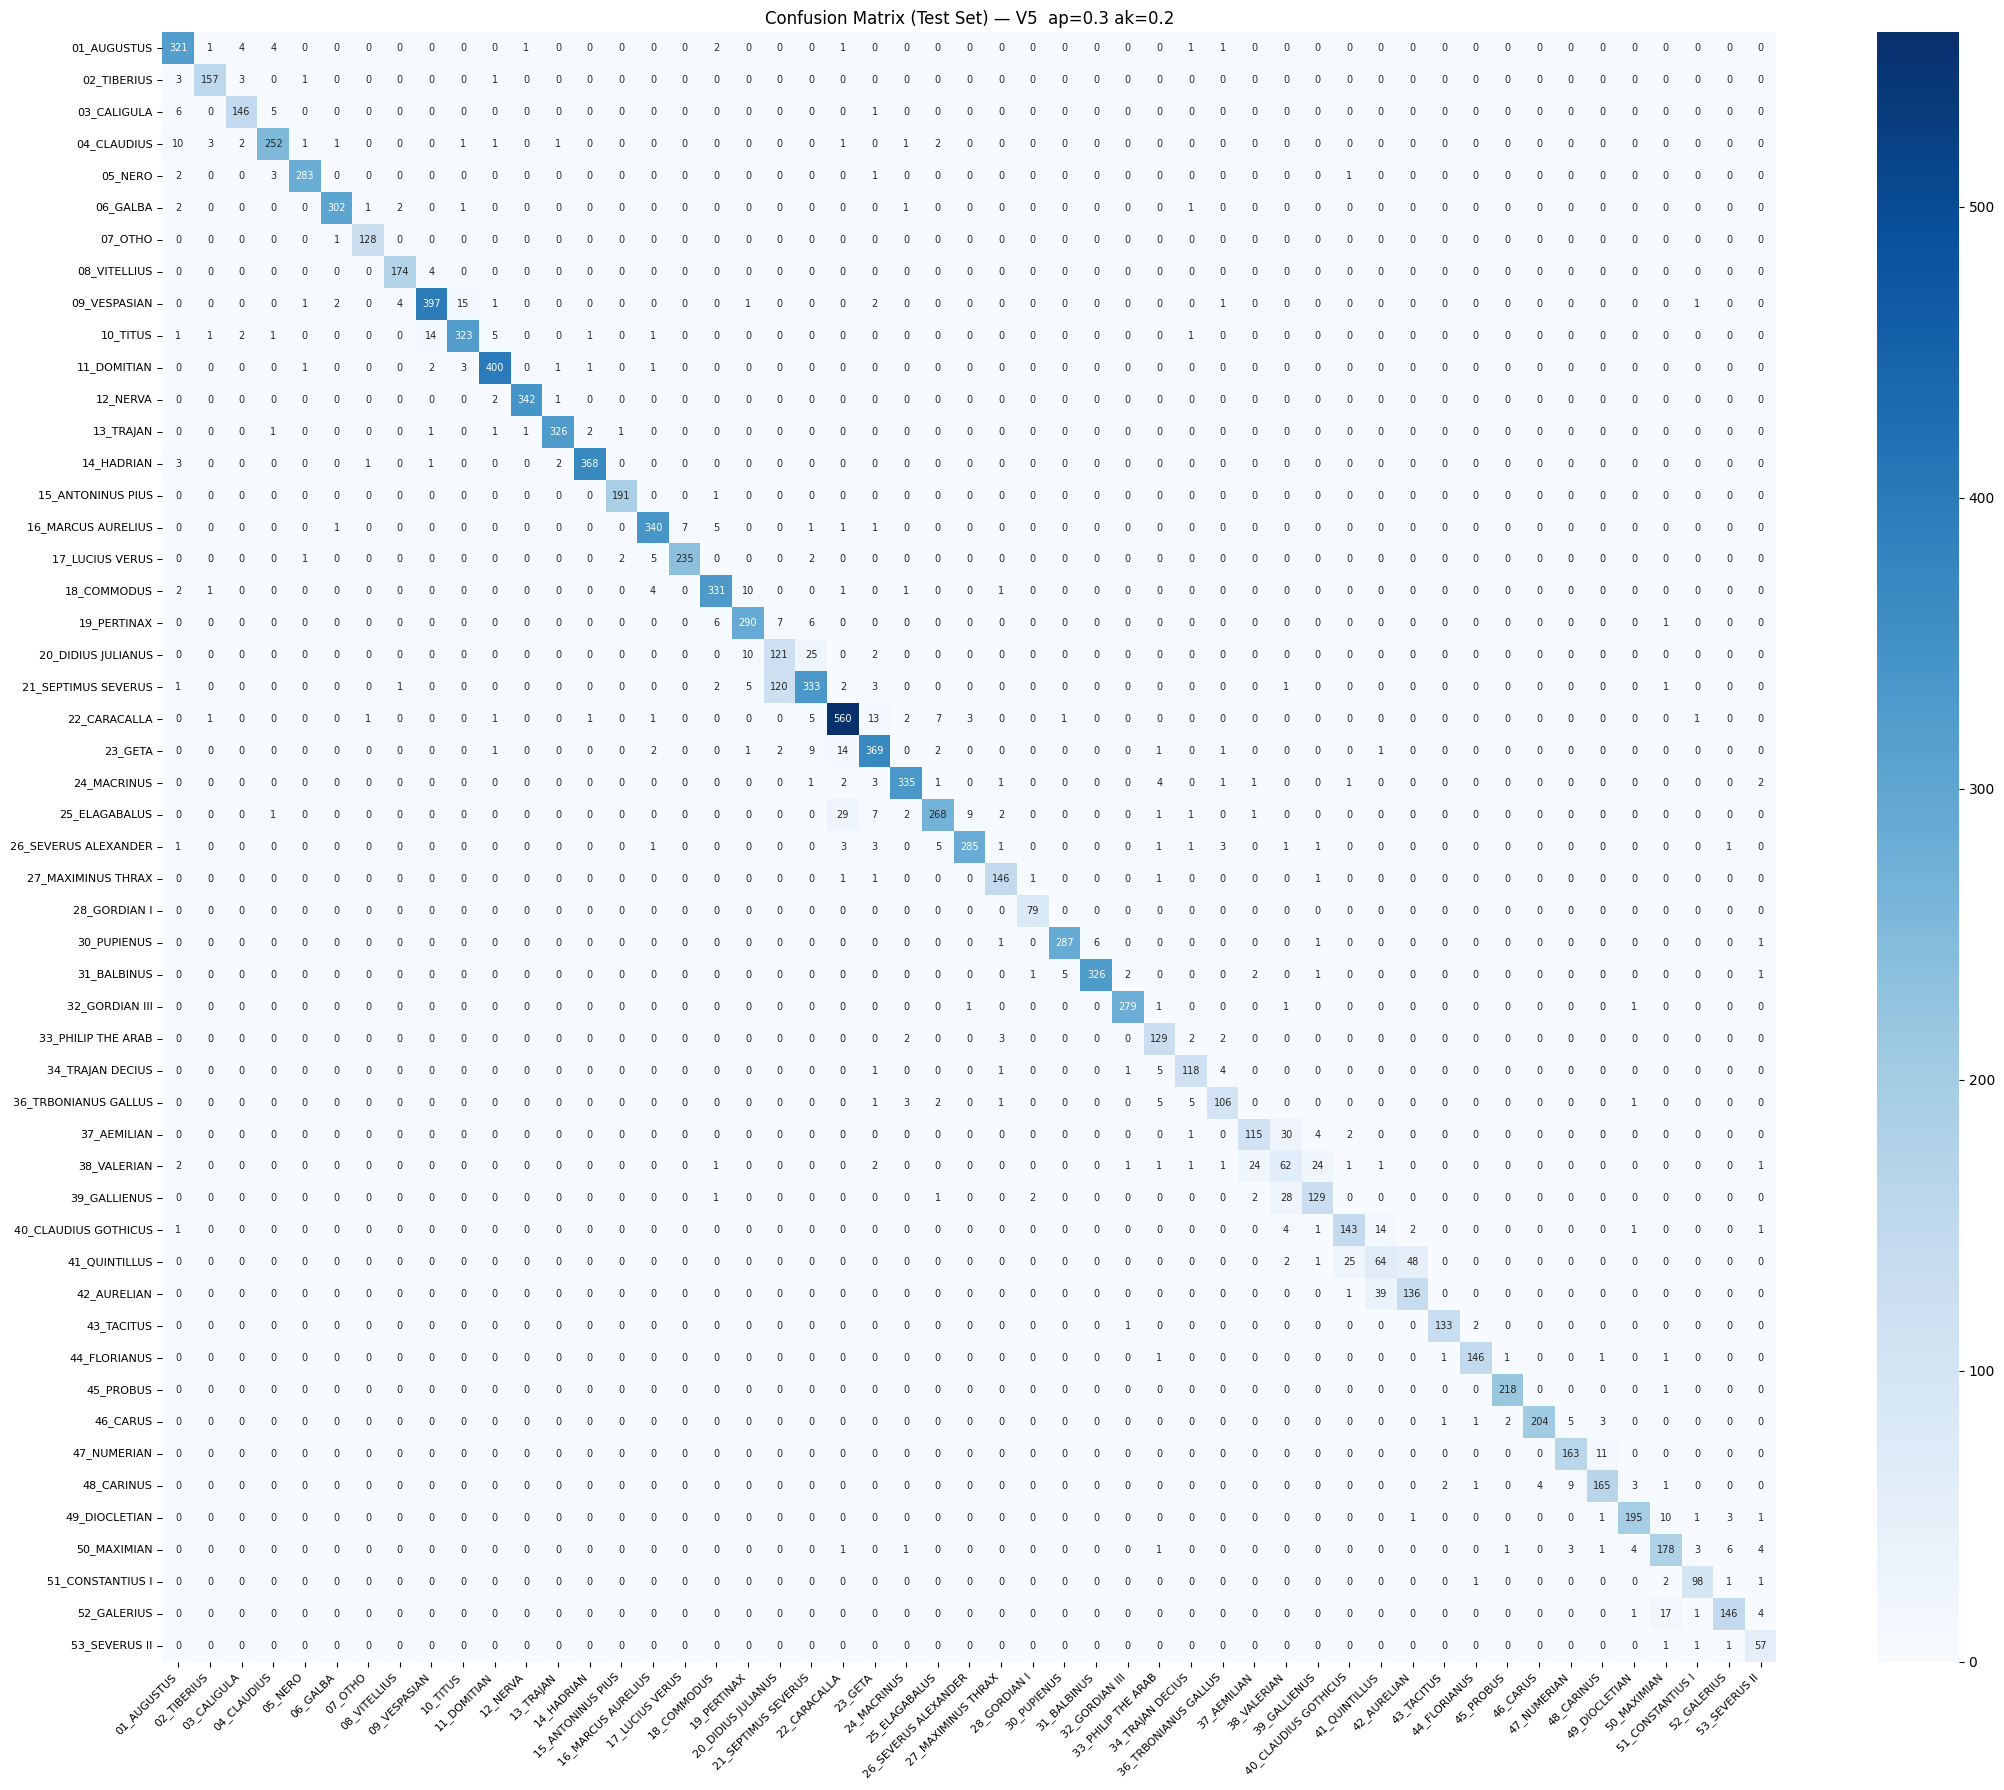

In [22]:
df_cm = pd.DataFrame(cm, index=display_names, columns=display_names)
plt.figure(figsize=(22, 18))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 7})
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title(f'Confusion Matrix (Test Set) — V5  ap={best_ap} ak={best_ak}')
plt.tight_layout()
plt.show()


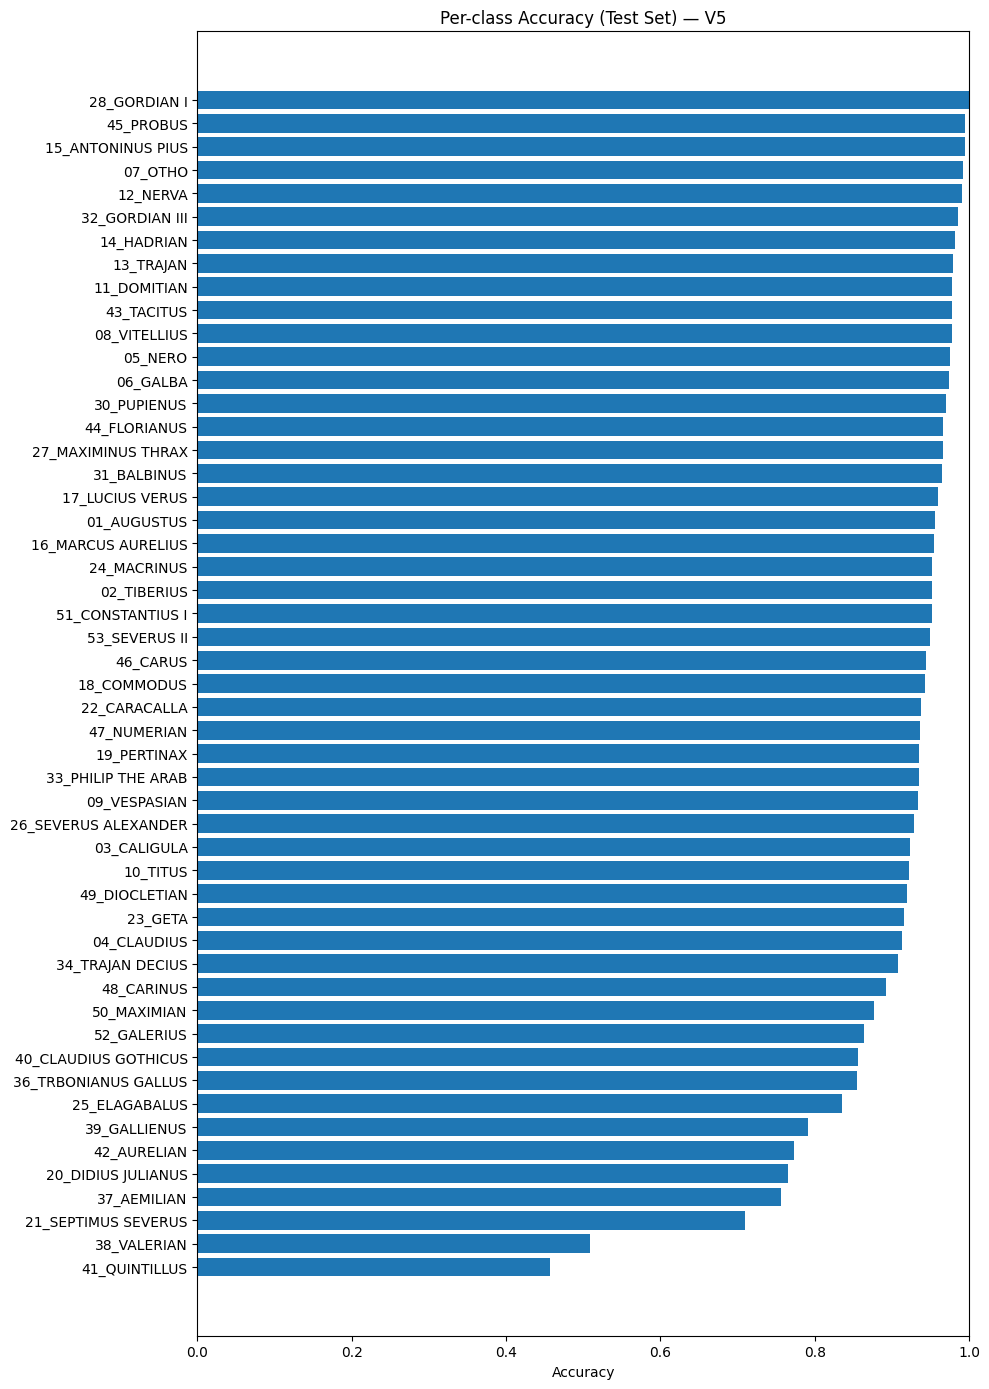

             Emperor  Accuracy
       41_QUINTILLUS  0.457143
         38_VALERIAN  0.508197
 21_SEPTIMUS SEVERUS  0.710021
         37_AEMILIAN  0.756579
  20_DIDIUS JULIANUS  0.765823
         42_AURELIAN  0.772727
        39_GALLIENUS  0.791411
       25_ELAGABALUS  0.834891
36_TRBONIANUS GALLUS  0.854839
40_CLAUDIUS GOTHICUS  0.856287
         52_GALERIUS  0.863905
         50_MAXIMIAN  0.876847
          48_CARINUS  0.891892
    34_TRAJAN DECIUS  0.907692
         04_CLAUDIUS  0.913043
             23_GETA  0.915633
       49_DIOCLETIAN  0.919811
            10_TITUS  0.922857
         03_CALIGULA  0.924051
26_SEVERUS ALEXANDER  0.928339
        09_VESPASIAN  0.934118
  33_PHILIP THE ARAB  0.934783
         19_PERTINAX  0.935484
         47_NUMERIAN  0.936782
        22_CARACALLA  0.938023
         18_COMMODUS  0.943020
            46_CARUS  0.944444
       53_SEVERUS II  0.950000
    51_CONSTANTIUS I  0.951456
         02_TIBERIUS  0.951515
         24_MACRINUS  0.951705
  16_MAR

In [23]:
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
acc_df = pd.DataFrame({'Emperor': display_names, 'Accuracy': per_class_acc}).sort_values('Accuracy')

plt.figure(figsize=(10, 14))
plt.barh(acc_df['Emperor'], acc_df['Accuracy'])
plt.xlabel('Accuracy')
plt.title('Per-class Accuracy (Test Set) — V5')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print(acc_df.to_string(index=False))
